In [1]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-07 10:16:37--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.04s   

2026-10-07 10:16:37 (15.3 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [8]:
df_work = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df_work.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: >

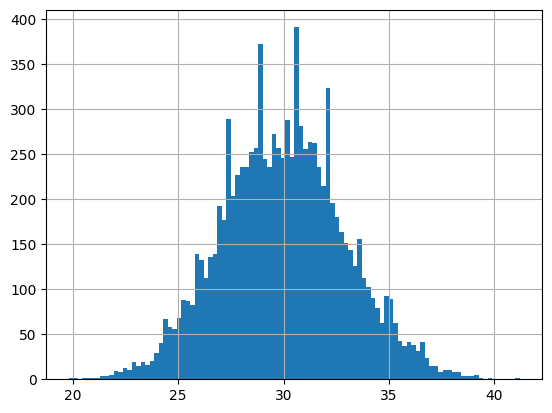

In [12]:
df['fuel_efficiency_mpg'].hist(bins=100)

In [13]:
df_work.isnull().sum()

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [ ]:
df_work['horsepower'].median()

254.0

In [ ]:
n = len(df_work)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_work.iloc[idx[:n_train]]
df_val = df_work.iloc[idx[n_train:n_train + n_val]]
df_test = df_work.iloc[idx[n_train + n_val:]]

In [17]:
df_work_zeros = df_work['horsepower'].fillna(0)
df_work_zeros.isnull().sum()

np.int64(0)

In [ ]:
# 1. Зберігаємо target для кожної вибірки окремо:
y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

# 2. Видаляємо цільову колонку:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [ ]:
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def prepare_X(df, fill_value):
    df_num = df[features].copy()
    df_num = df_num.fillna(fill_value)
    X = df_num.values
    return X

In [ ]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [ ]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [ ]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [ ]:
# Question 3: Evaluate fillna (zeros vs median)
def evaluate_model(fill_value, r=None):
    X_train = prepare_X(df_train, fill_value)

    if r is not None:
        w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    else:
        w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, fill_value)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    return round(score, 4)

median_val = df_train['horsepower'].median()
score_zeros = evaluate_model(fill_value=0)
score_median = evaluate_model(fill_value=median_val)

print(f'RMSE with zeros: {round(score_zeros, 3)}')
print(f'RMSE with median: {round(score_median, 3)}')

In [ ]:
# Question 4: Regularization
reg_params = [0, 0.01, 0.1, 1, 5, 10, 100]
print(f"{'r':>6} | {'RMSE':^8}")
print("-" * 17)
for r in reg_params:
    score = evaluate_model(fill_value=0, r=r)
    print(f"{r:>6} | {score:.4f}")

In [ ]:
# Question 5: Seed tuning
def train_val_test_split(df, seeds):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seeds)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy().reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy().reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].copy().reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val   = df_val['fuel_efficiency_mpg'].values
    y_test  = df_test['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    return df_train, df_val, df_test, y_train, y_val, y_test

In [ ]:
scores = []
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for i in seed_list:
    df_train, df_val, df_test, y_train, y_val, y_test = train_val_test_split(df_work, seeds=i)

    X_train = prepare_X(df_train, fill_value=0)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, fill_value=0)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)

    print(f'Seed {i}: RMSE = {score:.4f}')

In [ ]:
deviation = round(np.std(scores), 3)
print(f'Standard deviation: {deviation}')

In [ ]:
# Question 6: Final evaluation on test dataset
df_train, df_val, df_test, y_train, y_val, y_test = train_val_test_split(df_work, seeds=9)

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train, fill_value=0)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = prepare_X(df_test, fill_value=0)

y_pred_test = w0 + X_test.dot(w)

score_test = rmse(y_test, y_pred_test)
print(f'Final RMSE on test: {round(score_test, 3)}')